# Specific Stock Simulation

Simulate one stock from the earliest available date using daily aggregated index signals.

Trade sizing allows fractional shares and uses these rules:
- `STRONG BUY`: buy stock worth 10% of `initial_funds`
- `WEAK BUY`: buy stock worth 5% of `initial_funds`
- `HOLD`: do nothing
- `WEAK SELL`: sell 5% of current holdings
- `STRONG SELL`: sell 10% of current holdings

If cash or holdings are insufficient, the trade is capped at what is available.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import analysis_blocks


## Block 1: Parameters


In [2]:
chart_ticker = "UNH"
initial_funds = 1000
index_name = "dow30"  # options: sp500, nasdaq100, dow30
limit = 30  # reduce for quicker scans
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency
ticker_cache_dir = "cache"
ticker_cache_max_age_hours = 24


## Block 2: Run Stock Workflow


In [3]:
stock_result = analysis_blocks.run_specific_stock_simulation_workflow(
    tickers=[chart_ticker],
    initial_funds=initial_funds,
    include_sentiment=include_sentiment,
    include_fundamentals=include_fundamentals,
)

stock_result["prediction_summary"]


,current_date,TICKER,Signal,Signal_Text,cumulative_return,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio
0,20260314,UNH,1,WEAK BUY,Positive: Good,Positive: Bad,Negative: Poor,Negative: Poor,Positive: Good


## Block 3: Run Index Workflow


In [4]:
index_result = analysis_blocks.run_index_search_workflow(
    index_name=index_name,
    limit=limit,
    include_sentiment=include_sentiment,
    include_fundamentals=include_fundamentals,
    use_ticker_cache=True,
    ticker_cache_dir=ticker_cache_dir,
    ticker_cache_max_age_hours=ticker_cache_max_age_hours,
)

index_result["prediction_summary"].head(10)


,current_date,TICKER,Signal,Signal_Text,cumulative_return,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio
0,20260314,UNH,1,WEAK BUY,Positive: Good,Positive: Bad,Negative: Poor,Negative: Poor,Positive: Good
1,20260314,VZ,1,WEAK BUY,Positive: Good,Positive: Bad,Negative: Poor,Negative: Poor,Positive: Acceptable
2,20260314,JPM,1,WEAK BUY,Negative: Poor,Negative: Poor,Negative: Unacceptable,Negative: Poor,Negative: Poor
3,20260314,MMM,0,HOLD,Positive: Good,Positive: Bad,Negative: Poor,Negative: Poor,Positive: Acceptable
4,20260314,AMZN,0,HOLD,Positive: Good,Positive: Bad,Negative: Poor,Negative: Poor,Positive: Acceptable
5,20260314,BA,0,HOLD,Positive: Good,Positive: Bad,Negative: Poor,Negative: Poor,Positive: Acceptable
6,20260314,HON,0,HOLD,Positive: Good,Positive: Bad,Negative: Poor,Positive: Good,Positive: Acceptable
7,20260314,NKE,0,HOLD,Positive: Good,Positive: Bad,Positive: Good,Positive: Good,Positive: Excellent
8,20260314,CRM,0,HOLD,Positive: Good,Positive: Bad,Negative: Poor,Negative: Poor,Positive: Acceptable
9,20260314,DIS,0,HOLD,Positive: Excellent,Positive: Bad,Negative: Poor,Negative: Poor,Positive: Good


## Block 4: Build Daily Index Signal


In [5]:
price_history = analysis_blocks.get_price_history(stock_result["analyses"][chart_ticker]["df_pred"])

index_daily_signal = analysis_blocks.build_index_daily_signal_frame(
    index_result,
    start_date=price_history["Date"].min(),
    end_date=price_history["Date"].max(),
)

index_daily_signal.tail(30)


,Date,constituents,avg_signal_number,strong_sell_count,weak_sell_count,hold_count,weak_buy_count,strong_buy_count,signal_number,signal_text
1226,2026-01-30,30,0.166667,0,0,25,5,0,0,HOLD
1227,2026-02-02,30,0.166667,0,0,25,5,0,0,HOLD
1228,2026-02-03,30,0.200000,0,0,24,6,0,0,HOLD
1229,2026-02-04,30,0.200000,0,0,24,6,0,0,HOLD
1230,2026-02-05,30,0.200000,0,0,24,6,0,0,HOLD
1231,2026-02-06,30,0.133333,0,0,26,4,0,0,HOLD
1232,2026-02-09,30,0.166667,0,0,25,5,0,0,HOLD
1233,2026-02-10,30,0.133333,0,0,26,4,0,0,HOLD
1234,2026-02-11,30,0.166667,0,0,25,5,0,0,HOLD
1235,2026-02-12,30,0.200000,0,0,24,6,0,0,HOLD


## Block 5: Simulate Strategy


In [6]:
chart_simulation = analysis_blocks.simulate_index_signal_strategy(
    stock_result["analyses"][chart_ticker]["df_pred"],
    initial_funds=initial_funds,
    index_daily_signal_frame=index_daily_signal,
)


## Block 6: Portfolio Summary


In [7]:
chart_simulation["summary"]


,start_date,end_date,initial_funds,ending_cash_balance,units_held,average_cost_per_unit,latest_close,holdings_value,total_portfolio_value,profit_loss,profit_loss_pct,buy_transactions,sell_transactions
0,2021-03-15,2026-03-13,1000.0,900.0,0.199347,501.636797,282.089996,56.233912,956.233912,-43.766088,-4.376609,2,0


In [8]:
chart_simulation["transactions"]


,Date,action,signal_text,trade_price,units,trade_value,cash_balance,units_held,portfolio_value
0,2022-10-10,BUY,WEAK BUY,502.229996,0.099556,50.0,950.0,0.099556,999.664495
1,2022-10-12,BUY,WEAK BUY,501.044998,0.099791,50.0,900.0,0.199347,999.665733


## Block 7: Chart


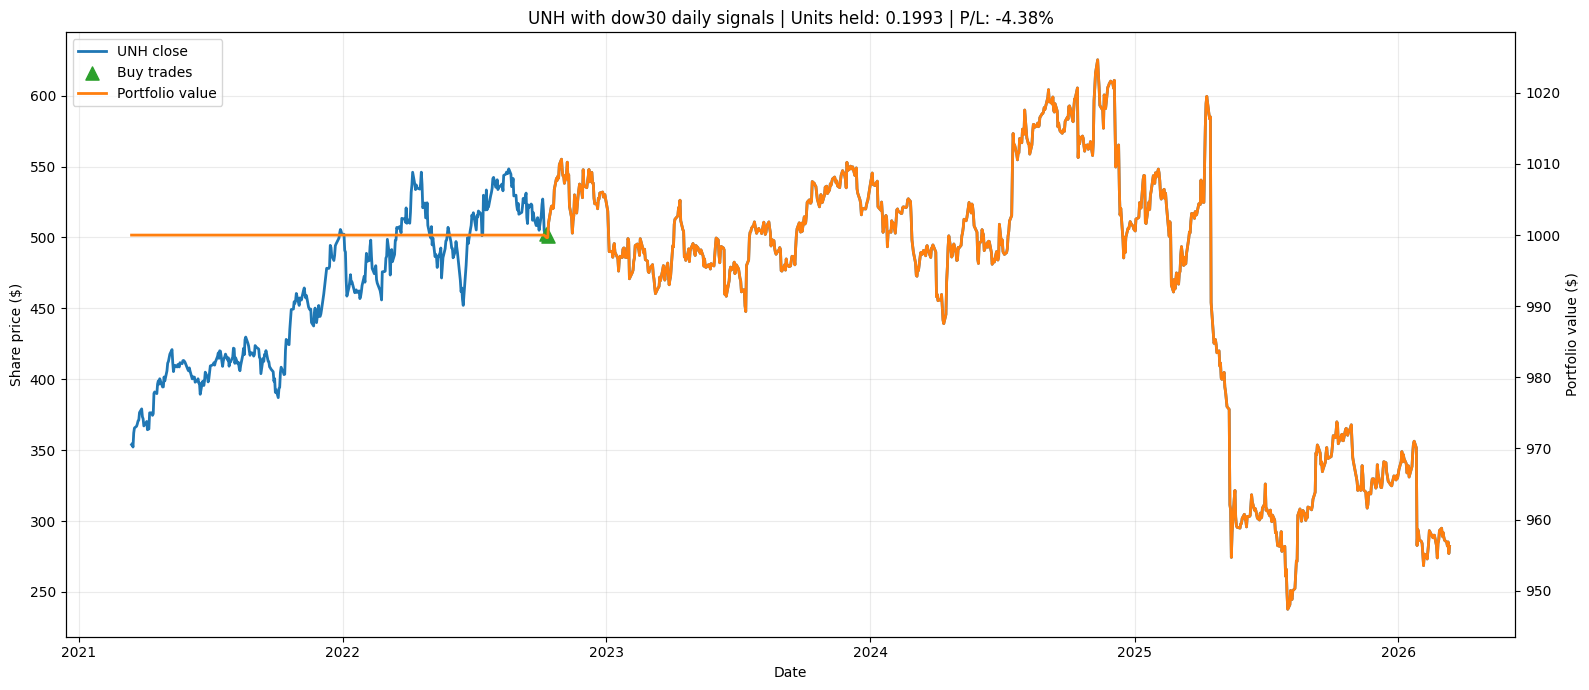

In [9]:
price_history = chart_simulation["price_history"].copy()
daily_history = chart_simulation["daily_history"].copy()
transactions = chart_simulation["transactions"].copy()
simulation_summary = chart_simulation["summary"].iloc[0]

buy_txns = transactions[transactions["action"] == "BUY"].copy()
sell_txns = transactions[transactions["action"] == "SELL"].copy()

fig, ax_price = plt.subplots(figsize=(16, 7))
ax_price.plot(
    price_history["Date"],
    price_history["Close"],
    color="#1f77b4",
    linewidth=2,
    label=f"{chart_ticker} close",
)

if not buy_txns.empty:
    ax_price.scatter(
        buy_txns["Date"],
        buy_txns["trade_price"],
        color="#2ca02c",
        marker="^",
        s=90,
        label="Buy trades",
        zorder=5,
    )

if not sell_txns.empty:
    ax_price.scatter(
        sell_txns["Date"],
        sell_txns["trade_price"],
        color="#d62728",
        marker="v",
        s=90,
        label="Sell trades",
        zorder=5,
    )

ax_price.set_xlabel("Date")
ax_price.set_ylabel("Share price ($)")
ax_price.grid(alpha=0.25)

ax_portfolio = ax_price.twinx()
ax_portfolio.plot(
    daily_history["Date"],
    daily_history["portfolio_value"],
    color="#ff7f0e",
    linewidth=2,
    label="Portfolio value",
)
ax_portfolio.set_ylabel("Portfolio value ($)")

title = (
    f"{chart_ticker} with {index_name} daily signals | "
    f"Units held: {simulation_summary['units_held']:.4f} | "
    f"P/L: {simulation_summary['profit_loss_pct']:.2f}%"
)
ax_price.set_title(title)

handles_price, labels_price = ax_price.get_legend_handles_labels()
handles_portfolio, labels_portfolio = ax_portfolio.get_legend_handles_labels()
ax_price.legend(handles_price + handles_portfolio, labels_price + labels_portfolio, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Block 8: Daily Portfolio History


In [11]:
chart_simulation["daily_history"][[
    "Date",
    "signal_text",
    "action",
    "trade_units",
    "trade_value",
    "cash_balance",
    "units_held",
    "holdings_value",
    "portfolio_value",
    "profit_loss_pct",
]].tail(365)


,Date,signal_text,action,trade_units,trade_value,cash_balance,units_held,holdings_value,portfolio_value,profit_loss_pct
891,2024-09-27,HOLD,HOLD,0.0,0.0,900.0,0.199347,115.990290,1015.990290,1.599029
892,2024-09-30,HOLD,HOLD,0.0,0.0,900.0,0.199347,116.554447,1016.554447,1.655445
893,2024-10-01,HOLD,HOLD,0.0,0.0,900.0,0.199347,116.279346,1016.279346,1.627935
894,2024-10-02,HOLD,HOLD,0.0,0.0,900.0,0.199347,118.075468,1018.075468,1.807547
895,2024-10-03,HOLD,HOLD,0.0,0.0,900.0,0.199347,118.163182,1018.163182,1.816318
...,...,...,...,...,...,...,...,...,...,...
1251,2026-03-09,HOLD,HOLD,0.0,0.0,900.0,0.199347,56.847906,956.847906,-4.315209
1252,2026-03-10,HOLD,HOLD,0.0,0.0,900.0,0.199347,56.283749,956.283749,-4.371625
1253,2026-03-11,HOLD,HOLD,0.0,0.0,900.0,0.199347,56.863851,956.863851,-4.313615
1254,2026-03-12,HOLD,HOLD,0.0,0.0,900.0,0.199347,55.229200,955.229200,-4.477080
